# Two POVs + Frozen Feature Extractor + Regression Head

This notebook trains and evaluates different combinations of frozen feature extractors, POV fusion strategies and regressors on the top+side dataset.


In [1]:
import datetime
import warnings
from IPython.display import display
from sklearn.model_selection import ParameterGrid
from src.helpers import *
from src.frozen_pipeline import *
from src.training_and_evaluation import *
from src.constants import *

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)


## Load Data


In [2]:
samples, image_paths = load_image_paths(CSV_PATH, TOP_FOLDER, SIDE_FOLDER)
print("Samples shape:", samples.shape)
display(samples[["exp_id", "volume", "top_path", "side_path"]].head())

Samples shape: (140, 23)


,exp_id,volume,top_path,side_path
0,1,38,photos\top_view_images\P2090072.JPG,photos\side_view_images\P2090161.JPG
1,1,57,photos\top_view_images\P2090073.JPG,photos\side_view_images\P2090163.JPG
2,1,76,photos\top_view_images\P2090074.JPG,photos\side_view_images\P2090167.JPG
3,2,19,photos\top_view_images\P2090075.JPG,photos\side_view_images\P2090171.JPG
4,2,38,photos\top_view_images\P2090076.JPG,photos\side_view_images\P2090173.JPG


## Show Regression Model Configurations


In [3]:
print("Grid sizes per regressor:")
for name, (_, grid) in REGRESSION_MODEL_CONFIGS.items():
    n = len(list(ParameterGrid(grid))) if grid else 1
    print(f"  {name:15s}: {n:4d}")

Grid sizes per regressor:
  linear         :    1
  mlp            :    6


## Nested CV Evaluation (split by experiment IDs) - Backbone X Fusion Mode X Regression Model

In [4]:
all_results = []
nested_artifacts = {}

for backbone_name in BACKBONE_NAMES:
    for fusion_name in FUSION_NAMES:
        print(f"\n{'#'*90}")
        print(f"Evaluating backbone={backbone_name}, fusion={fusion_name}")
        print(f"{'#'*90}")

        X, y, groups = build_feature_matrix(
            samples, backbone_name, fusion_name, EMBEDDING_CACHE_DIR, DEVICE,
            side_mask_path=SIDE_ROI_MASK,
            top_mask_path1=TOP_ROI_MASK_1,
            top_mask_path2=TOP_ROI_MASK_2
        )
        nested_results, oof_predictions = run_nested_cv(
            X=X,
            y=y,
            groups=groups,
            model_configs=REGRESSION_MODEL_CONFIGS,
            outer_splits=OUTER_SPLITS,
            inner_splits=INNER_SPLITS,
        )

        summary_df = summarise_nested_results(nested_results, backbone_name, fusion_name)
        all_results.append(summary_df)
        nested_artifacts[(backbone_name, fusion_name)] = {
            "X": X,
            "y": y,
            "groups": groups,
            "nested_results": nested_results,
            "oof_predictions": oof_predictions,
        }

results_df = pd.concat(all_results, ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean", "cv_r2_mean"],
    ascending=[True, True, False],
).reset_index(drop=True)



##########################################################################################
Evaluating backbone=vit_b_16, fusion=concat
##########################################################################################


vit_b_16 + concat: 100%|██████████| 140/140 [00:02<00:00, 52.13it/s]



GroupKFold | linear
Fold 1: MAE=6.663, RMSE=7.865, R2=0.862909729552812, best={}
Fold 2: MAE=5.732, RMSE=7.320, R2=0.8812609500631359, best={}
Fold 3: MAE=6.476, RMSE=7.820, R2=0.8643743225206809, best={}
Fold 4: MAE=8.219, RMSE=10.169, R2=0.7632381578256171, best={}
Fold 5: MAE=7.362, RMSE=8.628, R2=0.8397470873362142, best={}

GroupKFold | mlp
Fold 1: MAE=13.467, RMSE=16.351, R2=0.4075317137087322, best={'model__alpha': 0.01, 'model__learning_rate_init': 0.001}
Fold 2: MAE=9.498, RMSE=12.375, R2=0.6606243588857248, best={'model__alpha': 0.01, 'model__learning_rate_init': 0.001}
Fold 3: MAE=8.275, RMSE=10.193, R2=0.769561633036471, best={'model__alpha': 0.0001, 'model__learning_rate_init': 0.001}
Fold 4: MAE=12.040, RMSE=14.653, R2=0.5084004589844822, best={'model__alpha': 0.01, 'model__learning_rate_init': 0.001}
Fold 5: MAE=12.581, RMSE=15.076, R2=0.5106823456909342, best={'model__alpha': 0.01, 'model__learning_rate_init': 0.001}


## Show Selected Hyperparameters


In [5]:
for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    print(f"\n{'='*90}")
    print(f"backbone={backbone_name}, fusion={fusion_name}")
    print(f"{'='*90}")
    for regressor_name, folds in artifact["nested_results"].items():
        has_params = any(f["best_params"] for f in folds)
        if not has_params:
            continue
        print(regressor_name)
        for f in folds:
            print(f"  Fold {f['fold']}: {f['best_params']}")
        print()


backbone=vit_b_16, fusion=concat
mlp
  Fold 1: {'model__alpha': 0.01, 'model__learning_rate_init': 0.001}
  Fold 2: {'model__alpha': 0.01, 'model__learning_rate_init': 0.001}
  Fold 3: {'model__alpha': 0.0001, 'model__learning_rate_init': 0.001}
  Fold 4: {'model__alpha': 0.01, 'model__learning_rate_init': 0.001}
  Fold 5: {'model__alpha': 0.01, 'model__learning_rate_init': 0.001}



## Show Performance for All Configurations (best at the top)
Prints mean and standard deviation of MAE, MSE, RMSE, and R2 over the CV folds. Plots out-of-fold predictions for the best configurations.


,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_stc,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,vit_b_16,concat,linear,6.890482,0.843028,70.887197,17.584824,8.360300,0.996280,0.842306,0.041683
1,vit_b_16,concat,mlp,11.172131,1.959766,193.277502,57.798635,13.729581,2.185431,0.571360,0.127857


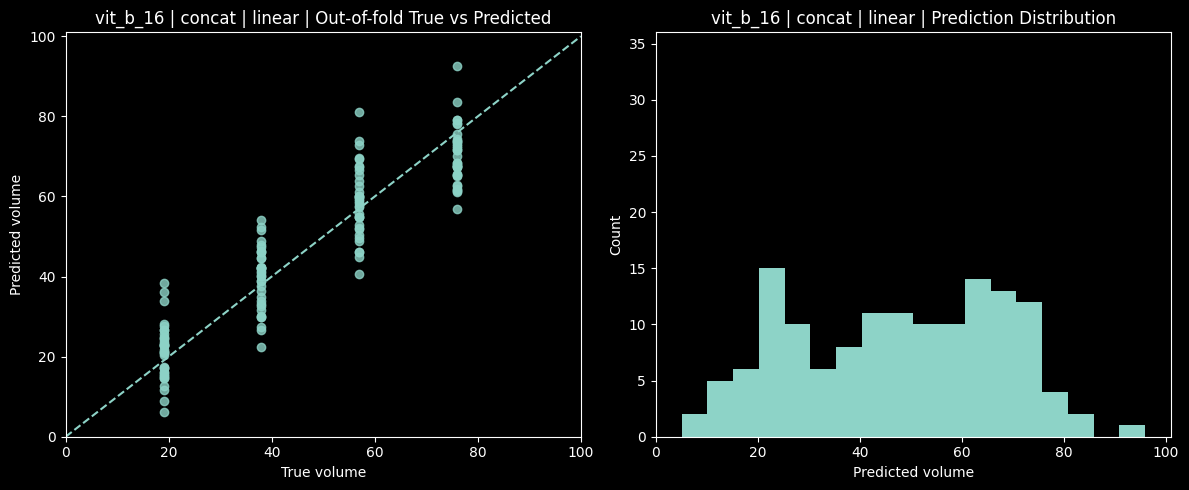

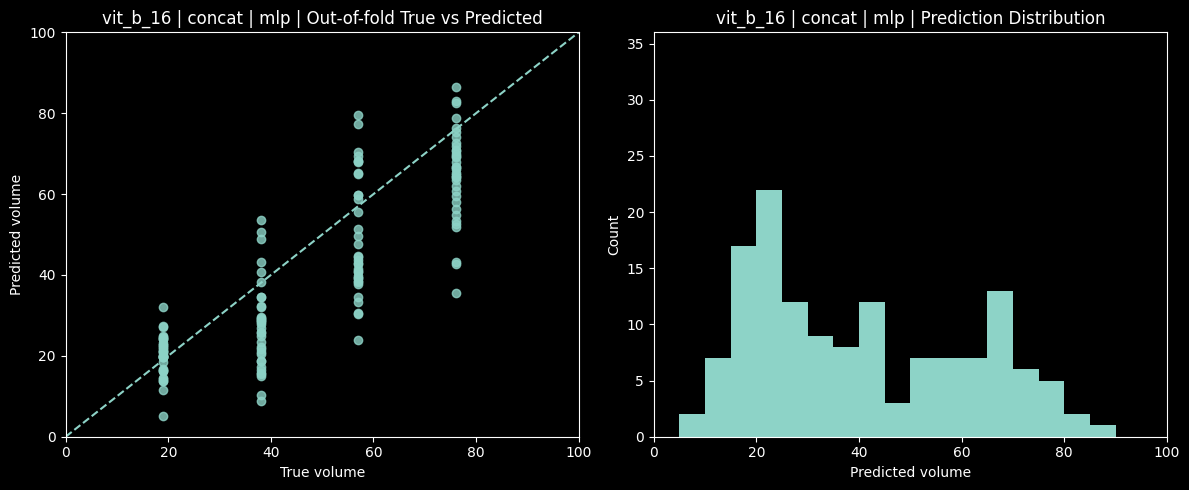

In [6]:
display(results_df)

for _, row in results_df.head(5).iterrows():
    key = (row["backbone"], row["fusion"])
    artifact = nested_artifacts[key]
    y_true = artifact["y"]
    y_pred = artifact["oof_predictions"][row["regressor"]]
    title = f"{row['backbone']} | {row['fusion']} | {row['regressor']}"
    make_oof_plot(y_true, y_pred, title_prefix=title)


## Save results


In [7]:
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
name = f"results_frozen_performance_{timestamp}.csv"
results_df.to_csv(OUTPUT_DIR / name, index=False)
print("Saved:", OUTPUT_DIR / name)

Saved: results\results_frozen_performance_2026-03-31_08-55-15.csv
